# เจาะลึกพฤติกรรมการใช้งาน Social Media

### Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

### Read Data

In [2]:
data = pd.read_csv("social_media_data.csv")
data.head()

,Timestamp,อายุ,เพศ,อาชีพ,ระยะเวลาการใช้งาน Social Media ต่อวัน,ช่วงเวลาในการใช้งาน Social Media บ่อยที่สุด,เหตุผลที่ชอบใช้งาน Social Media,ชอบใช้งานแอปพลิเคชันไหนมากที่สุด,เหตุผลที่ชอบใช้แอปพลิเคชันนี้,ใช้งานมานานแค่ไหนแล้ว
0,10/31/2025 23:18:48,20,หญิง,นักเรียน / นักศึกษา,มากกว่า 4 ชั่วโมง,12.00 - 18.00 น. (ช่วงบ่าย),ความบันเทิง – ผ่อนคลาย สนุก,YouTube,มีความบันเทิงสูง (วิดีโอ รูปภาพ เพลง ฯลฯ),มากกว่า 4 ปี
1,10/31/2025 23:21:05,20,ชาย,นักเรียน / นักศึกษา,มากกว่า 4 ชั่วโมง,18.00 - 24.00 น. (ช่วงกลางคืน),"การรับข้อมูล – เสพข่าว ความรู้, ความบันเทิง – ...",YouTube,"ใช้งานง่าย / สะดวก / ฟังก์ชันไม่ซับซ้อน, มีเนื...",มากกว่า 4 ปี
2,11/4/2025 12:22:14,61,หญิง,ไม่มีอาชีพ / ว่างงาน,1 - 2 ชั่วโมง,06.00 - 12.00 น. (ช่วงเช้า),ความบันเทิง – ผ่อนคลาย สนุก,Facebook,"มีเพื่อน / คนรู้จักใช้เยอะ, สามารถสื่อสาร พูดค...",1 - 2 ปี
3,11/4/2025 12:26:47,56,ชาย,ไม่มีอาชีพ / ว่างงาน,3 - 4 ชั่วโมง,12.00 - 18.00 น. (ช่วงบ่าย),"การรับข้อมูล – เสพข่าว ความรู้, ความบันเทิง – ...",Facebook,"ใช้งานง่าย / สะดวก / ฟังก์ชันไม่ซับซ้อน, มีควา...",มากกว่า 4 ปี
4,11/4/2025 12:42:46,20,หญิง,นักเรียน / นักศึกษา,มากกว่า 4 ชั่วโมง,18.00 - 24.00 น. (ช่วงกลางคืน),"การสื่อสาร – คุยกับคนอื่น, การรับข้อมูล – เสพข...",Tiktok,"ใช้งานง่าย / สะดวก / ฟังก์ชันไม่ซับซ้อน, มีเนื...",2 - 3 ปี


In [3]:
data.columns

Index(['Timestamp', 'อายุ', 'เพศ', 'อาชีพ',
       'ระยะเวลาการใช้งาน  Social Media ต่อวัน',
       'ช่วงเวลาในการใช้งาน  Social Media บ่อยที่สุด',
       'เหตุผลที่ชอบใช้งาน  Social Media', 'ชอบใช้งานแอปพลิเคชันไหนมากที่สุด ',
       'เหตุผลที่ชอบใช้แอปพลิเคชันนี้', 'ใช้งานมานานแค่ไหนแล้ว'],
      dtype='object')

In [4]:
print(f"Data size = {data.shape}")

Data size = (103, 10)


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103 entries, 0 to 102
Data columns (total 10 columns):
 #   Column                                        Non-Null Count  Dtype 
---  ------                                        --------------  ----- 
 0   Timestamp                                     103 non-null    object
 1   อายุ                                          103 non-null    object
 2   เพศ                                           103 non-null    object
 3   อาชีพ                                         103 non-null    object
 4   ระยะเวลาการใช้งาน  Social Media ต่อวัน        103 non-null    object
 5   ช่วงเวลาในการใช้งาน  Social Media บ่อยที่สุด  103 non-null    object
 6   เหตุผลที่ชอบใช้งาน  Social Media              103 non-null    object
 7   ชอบใช้งานแอปพลิเคชันไหนมากที่สุด              103 non-null    object
 8   เหตุผลที่ชอบใช้แอปพลิเคชันนี้                 103 non-null    object
 9   ใช้งานมานานแค่ไหนแล้ว                         103 non-null    object
dtypes:

In [6]:
data.isna().sum()

Timestamp                                       0
อายุ                                            0
เพศ                                             0
อาชีพ                                           0
ระยะเวลาการใช้งาน  Social Media ต่อวัน          0
ช่วงเวลาในการใช้งาน  Social Media บ่อยที่สุด    0
เหตุผลที่ชอบใช้งาน  Social Media                0
ชอบใช้งานแอปพลิเคชันไหนมากที่สุด                0
เหตุผลที่ชอบใช้แอปพลิเคชันนี้                   0
ใช้งานมานานแค่ไหนแล้ว                           0
dtype: int64

### Data Cleaning

#### 1. เปลี่ยนชื่อ Columns

In [7]:
rename_columns = {
    'อายุ': 'Age',
    'เพศ': 'Gender',
    'อาชีพ': 'Jobs',
    'ระยะเวลาการใช้งาน  Social Media ต่อวัน': 'DailyUsageHours',
    'ช่วงเวลาในการใช้งาน  Social Media บ่อยที่สุด': 'ActiveTime',
    'เหตุผลที่ชอบใช้งาน  Social Media': 'SocialMediaReason',
    'ชอบใช้งานแอปพลิเคชันไหนมากที่สุด ': 'FavoriteApp',
    'เหตุผลที่ชอบใช้แอปพลิเคชันนี้': 'AppReason',
    'ใช้งานมานานแค่ไหนแล้ว': 'UsageYears'
}

In [8]:
data.rename(columns=rename_columns, inplace=True)
data.head()

,Timestamp,Age,Gender,Jobs,DailyUsageHours,ActiveTime,SocialMediaReason,FavoriteApp,AppReason,UsageYears
0,10/31/2025 23:18:48,20,หญิง,นักเรียน / นักศึกษา,มากกว่า 4 ชั่วโมง,12.00 - 18.00 น. (ช่วงบ่าย),ความบันเทิง – ผ่อนคลาย สนุก,YouTube,มีความบันเทิงสูง (วิดีโอ รูปภาพ เพลง ฯลฯ),มากกว่า 4 ปี
1,10/31/2025 23:21:05,20,ชาย,นักเรียน / นักศึกษา,มากกว่า 4 ชั่วโมง,18.00 - 24.00 น. (ช่วงกลางคืน),"การรับข้อมูล – เสพข่าว ความรู้, ความบันเทิง – ...",YouTube,"ใช้งานง่าย / สะดวก / ฟังก์ชันไม่ซับซ้อน, มีเนื...",มากกว่า 4 ปี
2,11/4/2025 12:22:14,61,หญิง,ไม่มีอาชีพ / ว่างงาน,1 - 2 ชั่วโมง,06.00 - 12.00 น. (ช่วงเช้า),ความบันเทิง – ผ่อนคลาย สนุก,Facebook,"มีเพื่อน / คนรู้จักใช้เยอะ, สามารถสื่อสาร พูดค...",1 - 2 ปี
3,11/4/2025 12:26:47,56,ชาย,ไม่มีอาชีพ / ว่างงาน,3 - 4 ชั่วโมง,12.00 - 18.00 น. (ช่วงบ่าย),"การรับข้อมูล – เสพข่าว ความรู้, ความบันเทิง – ...",Facebook,"ใช้งานง่าย / สะดวก / ฟังก์ชันไม่ซับซ้อน, มีควา...",มากกว่า 4 ปี
4,11/4/2025 12:42:46,20,หญิง,นักเรียน / นักศึกษา,มากกว่า 4 ชั่วโมง,18.00 - 24.00 น. (ช่วงกลางคืน),"การสื่อสาร – คุยกับคนอื่น, การรับข้อมูล – เสพข...",Tiktok,"ใช้งานง่าย / สะดวก / ฟังก์ชันไม่ซับซ้อน, มีเนื...",2 - 3 ปี


#### 2. Age

In [9]:
data['Age'].value_counts()

Age
20       41
21       19
49        8
50        4
19        3
22        3
25        2
38        2
18        2
42        1
56        1
61        1
26        1
40        1
37        1
80 ปี     1
33        1
28        1
53        1
59        1
70        1
75        1
48        1
14        1
46        1
68        1
17        1
16        1
Name: count, dtype: int64

- ลบคำว่า 'ปี' ออกจาก Column อายุ

In [10]:
data['Age'] = data['Age'].astype(str).str.replace('ปี', '').str.strip()
data['Age'] = pd.to_numeric(data['Age'])
data['Age'].value_counts()

Age
20    41
21    19
49     8
50     4
19     3
22     3
25     2
38     2
18     2
42     1
56     1
61     1
26     1
40     1
37     1
80     1
33     1
28     1
53     1
59     1
70     1
75     1
48     1
14     1
46     1
68     1
17     1
16     1
Name: count, dtype: int64

- ทำการแบ่งช่วงอายุของผู้ตอบแบบสอบถาม

In [11]:
def getAgeGroup(age):
    age = int(age)
    if age < 20:
        return '0-19'
    elif 20 <= age <= 29:
        return '20-29'
    elif 30 <= age <= 39:
        return '30-39'
    elif 40 <= age <= 49:
        return '40-49'
    elif 50 <= age <= 59:
        return '50-59'
    else:
        return '60+'

In [12]:
data['AgeGroup'] = data['Age'].apply(getAgeGroup)
data['AgeGroup'].value_counts()

AgeGroup
20-29    67
40-49    12
0-19      8
50-59     7
60+       5
30-39     4
Name: count, dtype: int64

#### 3. Active Time

In [13]:
data['ActiveTime'].value_counts()

ActiveTime
18.00 - 24.00 น. (ช่วงกลางคืน)    70
12.00 - 18.00 น. (ช่วงบ่าย)       20
06.00 - 12.00 น. (ช่วงเช้า)        6
00.00 - 06.00 น. (ช่วงดึก)         2
ว่างๆก็เล่น                        1
เว้นช่วง00.00-07.00                1
08.00-18.00                        1
ทั้งวัน                            1
ทุกช่วงที่มีโอกาส                  1
Name: count, dtype: int64

- จัดการกับช่วงเวลาอื่น ๆ ที่ผู้ตอบแบบสอบถามกรอกเข้ามา

In [14]:
def cleanActiveTime(value):
    text = str(value).strip()

    if '18' in text and '24' in text:
        return '18.00 - 24.00 น. (ช่วงกลางคืน)'
    elif '12' in text and '18' in text:
        return '12.00 - 18.00 น. (ช่วงบ่าย)'
    elif '06' in text and '12' in text:
        return '06.00 - 12.00 น. (ช่วงเช้า)'
    elif '00' in text and '06' in text:
        return '00.00 - 06.00 น. (ช่วงดึก)'
    elif any(word in text for word in ['ทั้งวัน', 'ทุกช่วง', 'ว่าง', 'เว้น']):
        return 'อื่น ๆ / ไม่ระบุเวลา'
    else:
        return 'อื่น ๆ / ไม่ระบุเวลา'

In [15]:
data['ActiveTimeClean'] = data['ActiveTime'].apply(cleanActiveTime)
data['ActiveTimeClean'].value_counts()

ActiveTimeClean
18.00 - 24.00 น. (ช่วงกลางคืน)    70
12.00 - 18.00 น. (ช่วงบ่าย)       20
06.00 - 12.00 น. (ช่วงเช้า)        6
อื่น ๆ / ไม่ระบุเวลา               5
00.00 - 06.00 น. (ช่วงดึก)         2
Name: count, dtype: int64

#### 4. Favorite App

In [16]:
data['FavoriteApp'].value_counts()

FavoriteApp
Tiktok         39
Instagram      19
Facebook       16
YouTube        16
Twitter (X)    10
Good note       1
readawrite      1
line            1
Name: count, dtype: int64

- จัดการกับ Social Media อื่น ๆ ที่ผู้ตอบแบบสอบถามกรอกเข้ามา

In [17]:
social_media = ['Facebook', 'Instagram', 'Tiktok', 'Twitter (X)', 'YouTube']
data['FavoriteAppClean'] = data['FavoriteApp'].apply(
    lambda x: x if x in social_media else 'Others'
)

In [18]:
data['FavoriteAppClean'].value_counts()

FavoriteAppClean
Tiktok         39
Instagram      19
Facebook       16
YouTube        16
Twitter (X)    10
Others          3
Name: count, dtype: int64

#### 5. Social Media Reason

- แยกเหตุผลที่ชอบใช้งาน Social Media ที่ผู้ตอบแบบสอบถามเลือก (หลายคำตอบ)

In [19]:
data['SocialMediaReasonList'] = data['SocialMediaReason'].astype(str).str.split(',')
SocialMediaReasonCounts = data.explode('SocialMediaReasonList')['SocialMediaReasonList'].str.strip().value_counts()
SocialMediaReasonCounts

SocialMediaReasonList
ความบันเทิง – ผ่อนคลาย สนุก                          95
การรับข้อมูล – เสพข่าว ความรู้                       75
การสื่อสาร – คุยกับคนอื่น                            66
ประโยชน์เฉพาะทาง – ใช้ทำงาน ทำธุรกิจ หรือการศึกษา    32
การแสดงตัวตน – โพสต์ แชร์ สร้างภาพลักษณ์             23
Name: count, dtype: int64

#### 6. App Reason

-  แยกเหตุผลที่ชอบใช้แอปพลิเคชันที่เลือก ที่ผู้ตอบแบบสอบถามเลือก (หลายคำตอบ)

In [20]:
import re

In [21]:
def textSplit(text):
    text = re.sub(r'\(([^)]*)\)', lambda m: '(' + m.group(1).replace(',', ';') + ')', str(text))
    return [p.strip() for p in text.split(', ') if p.strip()]

In [22]:
data['AppReasonList'] = data['AppReason'].apply(textSplit)
appReasonCounts = (data.explode('AppReasonList')['AppReasonList']
                .str.replace(',', ';', regex=False)
                .str.strip()
                .value_counts())
appReasonCounts

AppReasonList
มีความบันเทิงสูง (วิดีโอ รูปภาพ เพลง ฯลฯ)                                  65
ใช้งานง่าย / สะดวก / ฟังก์ชันไม่ซับซ้อน                                    63
มีเนื้อหาที่ตรงกับความสนใจ                                                 58
ใช้เพื่อติดตามข่าวสารหรือเหตุการณ์ปัจจุบันได้รวดเร็ว                       45
สามารถสื่อสาร พูดคุย หรือเชื่อมต่อกับผู้อื่นได้สะดวก                       37
ใช้เพื่อติดตามบุคคลหรือเพจที่ชื่นชอบ (ดารา; อินฟลูเอนเซอร์; แบรนด์ ฯลฯ)    34
มีเพื่อน / คนรู้จักใช้เยอะ                                                 31
เหมาะกับการแสดงออก / โพสต์รูป / วิดีโอ / ความคิดเห็นของตัวเอง              19
มีระบบแนะนำคอนเทนต์ (Algorithm) ที่ตรงใจ                                   14
แอปพลิเคชันมีความน่าเชื่อถือ / ปลอดภัย / เสถียร                            13
สามารถใช้เพื่อขายของ / โปรโมตสินค้า / ทำธุรกิจได้ดี                         9
Name: count, dtype: int64

#### 7. Jobs

- เปลี่ยนชื่ออาชีพให้สั้นลง

In [23]:
jobs_rename = {
    'ข้าราชการ / พนักงานรัฐวิสาหกิจ': 'ข้าราชการ',
    'ค้าขาย / พ่อค้าแม่ค้า': 'ค้าขาย',
    'นักเรียน / นักศึกษา': 'นักเรียน',
    'พนักงานบริษัทเอกชน': 'พนักงานบริษัท',
    'วิศวกร / ช่างเทคนิค / IT / นักวิทยาศาสตร์': 'วิศวกร / IT',
    'เจ้าของธุรกิจ / ผู้ประกอบการ / ฟรีแลนซ์': 'ผู้ประกอบการ',
    'ไม่มีอาชีพ / ว่างงาน': 'ว่างงาน'
}

In [24]:
data['JobsRename'] = data['Jobs'].replace(jobs_rename)

#### 8. สร้าง DataFrame ใหม่ที่ Clean แล้ว

In [25]:
columns = ['Age', 'Gender', 'Jobs', 'JobsRename', 'DailyUsageHours', 'ActiveTimeClean', 'SocialMediaReason', 'AppReason', 'UsageYears', 'FavoriteAppClean', 'AgeGroup']

In [26]:
new_data = data[columns]
new_data.head()

,Age,Gender,Jobs,JobsRename,DailyUsageHours,ActiveTimeClean,SocialMediaReason,AppReason,UsageYears,FavoriteAppClean,AgeGroup
0,20,หญิง,นักเรียน / นักศึกษา,นักเรียน,มากกว่า 4 ชั่วโมง,12.00 - 18.00 น. (ช่วงบ่าย),ความบันเทิง – ผ่อนคลาย สนุก,มีความบันเทิงสูง (วิดีโอ รูปภาพ เพลง ฯลฯ),มากกว่า 4 ปี,YouTube,20-29
1,20,ชาย,นักเรียน / นักศึกษา,นักเรียน,มากกว่า 4 ชั่วโมง,18.00 - 24.00 น. (ช่วงกลางคืน),"การรับข้อมูล – เสพข่าว ความรู้, ความบันเทิง – ...","ใช้งานง่าย / สะดวก / ฟังก์ชันไม่ซับซ้อน, มีเนื...",มากกว่า 4 ปี,YouTube,20-29
2,61,หญิง,ไม่มีอาชีพ / ว่างงาน,ว่างงาน,1 - 2 ชั่วโมง,06.00 - 12.00 น. (ช่วงเช้า),ความบันเทิง – ผ่อนคลาย สนุก,"มีเพื่อน / คนรู้จักใช้เยอะ, สามารถสื่อสาร พูดค...",1 - 2 ปี,Facebook,60+
3,56,ชาย,ไม่มีอาชีพ / ว่างงาน,ว่างงาน,3 - 4 ชั่วโมง,12.00 - 18.00 น. (ช่วงบ่าย),"การรับข้อมูล – เสพข่าว ความรู้, ความบันเทิง – ...","ใช้งานง่าย / สะดวก / ฟังก์ชันไม่ซับซ้อน, มีควา...",มากกว่า 4 ปี,Facebook,50-59
4,20,หญิง,นักเรียน / นักศึกษา,นักเรียน,มากกว่า 4 ชั่วโมง,18.00 - 24.00 น. (ช่วงกลางคืน),"การสื่อสาร – คุยกับคนอื่น, การรับข้อมูล – เสพข...","ใช้งานง่าย / สะดวก / ฟังก์ชันไม่ซับซ้อน, มีเนื...",2 - 3 ปี,Tiktok,20-29


### Data Visualization

- กำหนด Style และ Theme

In [27]:
import matplotlib.font_manager as fm

sns.set_theme(style="whitegrid")

font_path = 'Kanit-Regular.ttf'
fm.fontManager.addfont(font_path)
# print(fm.FontProperties(fname=font_path).get_name()) # Kanit

plt.rcParams.update({
    'font.family': 'Kanit',
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 16,
})

In [28]:
new_data.head()

,Age,Gender,Jobs,JobsRename,DailyUsageHours,ActiveTimeClean,SocialMediaReason,AppReason,UsageYears,FavoriteAppClean,AgeGroup
0,20,หญิง,นักเรียน / นักศึกษา,นักเรียน,มากกว่า 4 ชั่วโมง,12.00 - 18.00 น. (ช่วงบ่าย),ความบันเทิง – ผ่อนคลาย สนุก,มีความบันเทิงสูง (วิดีโอ รูปภาพ เพลง ฯลฯ),มากกว่า 4 ปี,YouTube,20-29
1,20,ชาย,นักเรียน / นักศึกษา,นักเรียน,มากกว่า 4 ชั่วโมง,18.00 - 24.00 น. (ช่วงกลางคืน),"การรับข้อมูล – เสพข่าว ความรู้, ความบันเทิง – ...","ใช้งานง่าย / สะดวก / ฟังก์ชันไม่ซับซ้อน, มีเนื...",มากกว่า 4 ปี,YouTube,20-29
2,61,หญิง,ไม่มีอาชีพ / ว่างงาน,ว่างงาน,1 - 2 ชั่วโมง,06.00 - 12.00 น. (ช่วงเช้า),ความบันเทิง – ผ่อนคลาย สนุก,"มีเพื่อน / คนรู้จักใช้เยอะ, สามารถสื่อสาร พูดค...",1 - 2 ปี,Facebook,60+
3,56,ชาย,ไม่มีอาชีพ / ว่างงาน,ว่างงาน,3 - 4 ชั่วโมง,12.00 - 18.00 น. (ช่วงบ่าย),"การรับข้อมูล – เสพข่าว ความรู้, ความบันเทิง – ...","ใช้งานง่าย / สะดวก / ฟังก์ชันไม่ซับซ้อน, มีควา...",มากกว่า 4 ปี,Facebook,50-59
4,20,หญิง,นักเรียน / นักศึกษา,นักเรียน,มากกว่า 4 ชั่วโมง,18.00 - 24.00 น. (ช่วงกลางคืน),"การสื่อสาร – คุยกับคนอื่น, การรับข้อมูล – เสพข...","ใช้งานง่าย / สะดวก / ฟังก์ชันไม่ซับซ้อน, มีเนื...",2 - 3 ปี,Tiktok,20-29


#### Insight 1 - แอปพลิเคชันยอดนิยมตามช่วงอายุ

In [29]:
cross_tab_prop = pd.crosstab(index=data['AgeGroup'], columns=data['FavoriteAppClean'])
cross_tab_prop

FavoriteAppClean,Facebook,Instagram,Others,Tiktok,Twitter (X),YouTube
AgeGroup,,,,,,
0-19,0,4,1,3,0,0
20-29,0,14,2,32,10,9
30-39,3,0,0,0,0,1
40-49,6,1,0,3,0,2
50-59,4,0,0,1,0,2
60+,3,0,0,0,0,2


In [30]:
cross_tab_percent = cross_tab_prop.div(cross_tab_prop.sum(1), axis=0) * 100

<Figure size 1200x700 with 0 Axes>

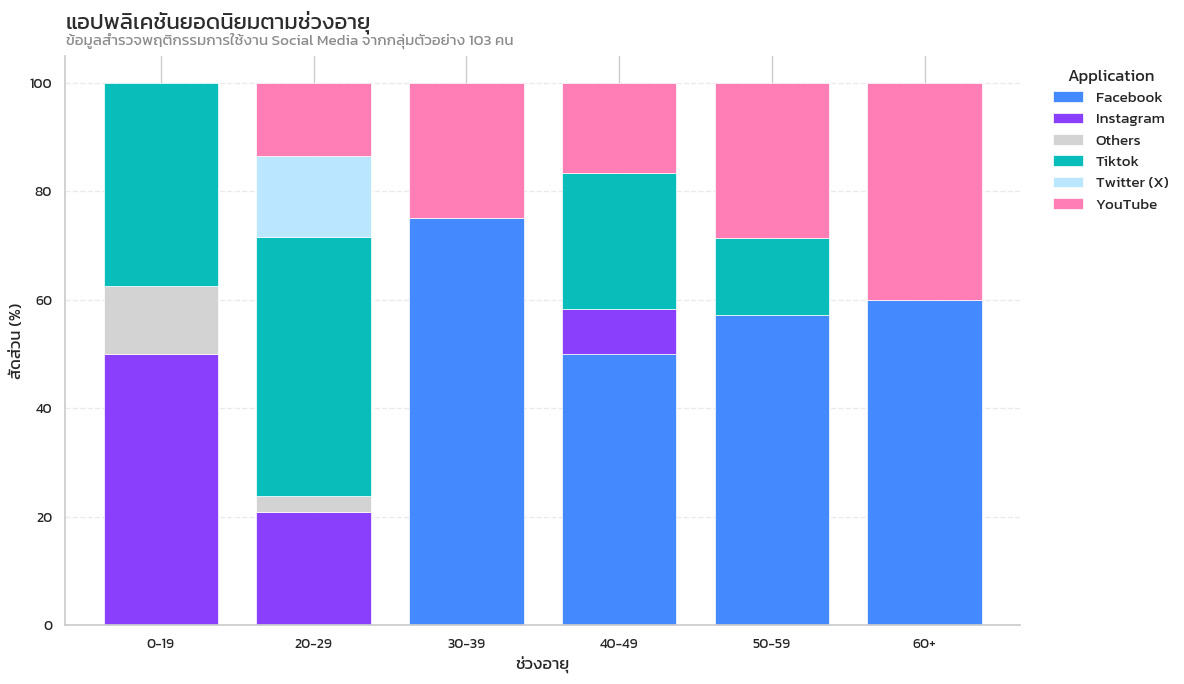

In [31]:
colors = ['#4589ff', '#8a3ffc', '#d3d3d3', '#08bdba', '#bae6ff', '#ff7eb6']

total_survey = len(new_data)
subtitle_text = f"ข้อมูลสำรวจพฤติกรรมการใช้งาน Social Media จากกลุ่มตัวอย่าง {total_survey} คน"

plt.figure(figsize=(12, 7))
cross_tab_percent.plot(kind='bar',
                    stacked=True,
                    color=colors,
                    figsize=(12, 7),
                    width=0.75,
                    edgecolor='white',
                    linewidth=0.5)
sns.despine()
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.xlabel('ช่วงอายุ')
plt.ylabel('สัดส่วน (%)')
plt.title("แอปพลิเคชันยอดนิยมตามช่วงอายุ", loc='left', fontsize=16, fontweight='bold', color='#2c2c2c', pad=20)
plt.text(x=-0.62, y=107, s=subtitle_text, fontsize=11, color='#8c8c8c')
plt.legend(title='Application', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

**จากกราฟที่ได้ พบประเด็นที่สำคัญดังนี้**
- ผู้ใช้งานในกลุ่มอายุน้อยกว่า 30 ปี มีแนวโน้มใช้งาน Facebook กันน้อยลง และให้ความสนใจกับแอปพลิเคชันที่เน้นด้านคอนเทนต์ภาพและวิดีโอสั้นอย่าง TikTok และ Instagram กันมากขึ้น
- ในกลุ่มอายุ 30 ปีขึ้นไป ยังคงใช้ Facebook เป็นแอปพลิเคชันหลัก โดยมีสัดส่วนการใช้งานเกินกว่าร้อยละ 50 ในทุกช่วงวัย ซึ่งอาจเนื่องมาจากกลุ่มเพื่อน ครอบครัว และคนสนิทใกล้ชิด ที่ยังคงอยู่ในแอปพลิเคชันนี้
- ในกลุ่มนักเรียน นักศึกษา (อายุต่ำกว่า 20 ปี) พบว่า TikTok มีอิทธิพลมากที่สุด ตามมาด้วย Instagram ซึ่งสะท้อนให้เห็นถึงพฤติกรรมการเสพสื่อที่ต้องการความรวดเร็ว ความบันเทิง และความสนใจเฉพาะบุคคล

#### Insight 2 - ความแตกต่างทางเพศกับการเลือกใช้แอปพลิเคชัน

In [32]:
new_data['Gender'].value_counts()

Gender
หญิง     67
ชาย      34
อื่นๆ     2
Name: count, dtype: int64

- ทำการ filter เพศ โดยเลือกเฉพาะเพศชายและหญิง

In [33]:
data_gender = new_data[new_data['Gender'].isin(['ชาย', 'หญิง'])].copy()

In [34]:
gender_app_counts = data_gender.groupby(['Gender', 'FavoriteAppClean']).size().reset_index(name='Count')
gender_total = data_gender['Gender'].value_counts().reset_index()
gender_total.columns = ['Gender', 'Total_Count']
gender_app_percent = pd.merge(gender_app_counts, gender_total, on='Gender')
gender_app_percent['Percentage'] = (gender_app_percent['Count'] / gender_app_percent['Total_Count']) * 100

In [35]:
gender_app_percent

,Gender,FavoriteAppClean,Count,Total_Count,Percentage
0,ชาย,Facebook,7,34,20.588235
1,ชาย,Instagram,8,34,23.529412
2,ชาย,Tiktok,12,34,35.294118
3,ชาย,YouTube,7,34,20.588235
4,หญิง,Facebook,9,67,13.432836
5,หญิง,Instagram,10,67,14.925373
6,หญิง,Others,3,67,4.477612
7,หญิง,Tiktok,27,67,40.298507
8,หญิง,Twitter (X),10,67,14.925373
9,หญิง,YouTube,8,67,11.940299


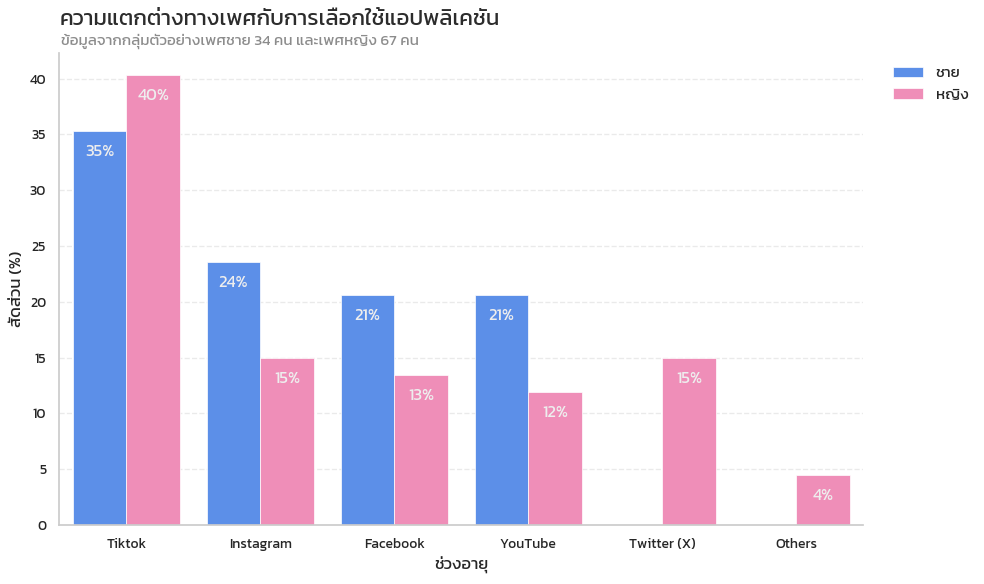

In [36]:
gender_colors = {'ชาย': '#4589ff', 'หญิง': '#ff7eb6'}

gender_counts = new_data['Gender'].value_counts()

total_male = gender_counts.get('ชาย', 0)
total_female = gender_counts.get('หญิง', 0)
subtitle_text2 = f"ข้อมูลจากกลุ่มตัวอย่างเพศชาย {total_male} คน และเพศหญิง {total_female} คน"

order = data_gender['FavoriteAppClean'].value_counts().index

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=gender_app_percent,
    x='FavoriteAppClean',
    y='Percentage',
    hue='Gender',
    order=order,
    palette=gender_colors,
    edgecolor='white',
    linewidth=0.5
)
sns.despine()
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.title("ความแตกต่างทางเพศกับการเลือกใช้แอปพลิเคชัน", loc='left', fontsize=16, fontweight='bold', color='#2c2c2c', pad=20)
plt.xlabel('ช่วงอายุ')
plt.ylabel('สัดส่วน (%)')
plt.text(x=-0.49, y=43, s=subtitle_text2, fontsize=11, color='#8c8c8c')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f%%', padding=-20, color='#eeeeee')
    
plt.tight_layout()
plt.show()

**จากกราฟที่ได้ พบประเด็นที่สำคัญดังนี้**
- ผู้ใช้งานในกลุ่มเพศชายมีแนวโน้มเลือกใช้งาน Instagram, Facebook และ YouTube เป็นแอปพลิเคชันหลักในสัดส่วนที่สูงกว่าเพศหญิง ซึ่งสะท้อนให้เห็นถึงพฤติกรรมการเสพคอนเทนต์แบบวิดีโอยาว ๆ หรือการดูสตรีมมิ่งมากกว่าผู้หญิง
- Twitter (X) ได้รับความนิยมเฉพาะในกลุ่มเพศหญิงร้อยละ 15 ในขณะที่กลุ่มเพศชายไม่พบผู้ใช้งานหลัก
- ส่วนแอปพลิเคชัน TikTok มีการใช้งานในระดับสูงทั้งในกลุ่มเพศชายและเพศหญิง แสดงให้เห็นว่าคอนเทนต์แบบวิดีโอสั้น กระชับ เป็นสื่อที่สามารถเข้าถึงกลุ่มเป้าหมายได้ครอบคลุมทุกเพศ

#### Insight 3 - จัดอันดับเหตุผลที่ชอบใช้งาน Social Media

In [37]:
reason_counts = SocialMediaReasonCounts.reset_index()
reason_counts.columns = ['Reason', 'Count']
reason_counts['Percentage'] = (reason_counts['Count'] / len(new_data)) * 100
reason_counts

,Reason,Count,Percentage
0,ความบันเทิง – ผ่อนคลาย สนุก,95,92.233010
1,การรับข้อมูล – เสพข่าว ความรู้,75,72.815534
2,การสื่อสาร – คุยกับคนอื่น,66,64.077670
3,ประโยชน์เฉพาะทาง – ใช้ทำงาน ทำธุรกิจ หรือการศึกษา,32,31.067961
4,การแสดงตัวตน – โพสต์ แชร์ สร้างภาพลักษณ์,23,22.330097


C:\Users\ASUS\AppData\Local\Temp\ipykernel_26632\1718163442.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


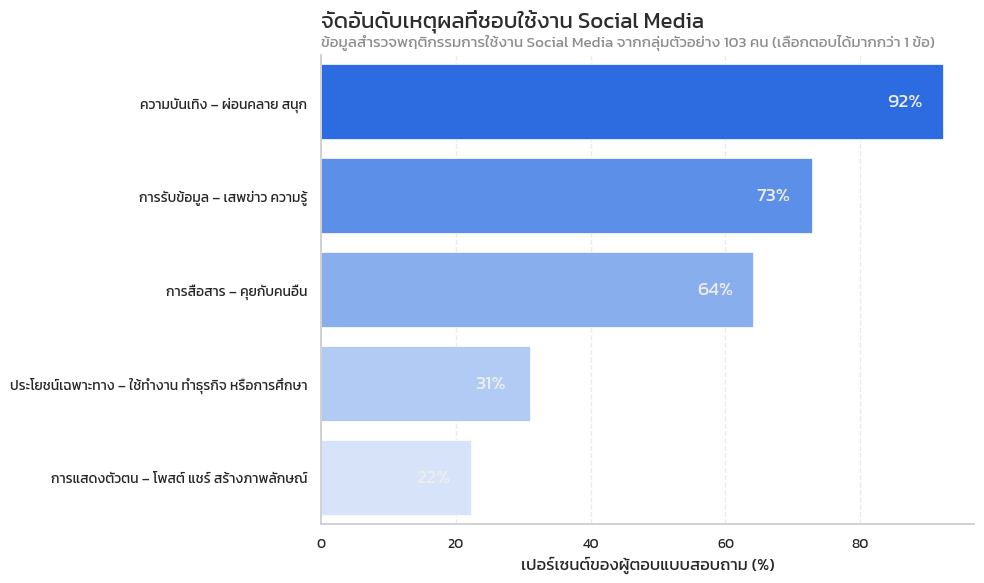

In [38]:
reason_colors = ['#0f62fe', '#4589ff', '#78a9ff', '#a6c8ff', '#d0e2ff']

subtitle_text3 = f"ข้อมูลสำรวจพฤติกรรมการใช้งาน Social Media จากกลุ่มตัวอย่าง {total_survey} คน (เลือกตอบได้มากกว่า 1 ข้อ)"

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=reason_counts,
    x='Percentage',
    y='Reason',
    palette=reason_colors,
    edgecolor='white',
    linewidth=0.5
)

sns.despine()
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.title("จัดอันดับเหตุผลที่ชอบใช้งาน Social Media", loc='left', fontsize=16, fontweight='bold', color='#2c2c2c', pad=20)
plt.text(x=0, y=-0.6, s=subtitle_text3, fontsize=11, color='#8c8c8c')
plt.xlabel('เปอร์เซนต์ของผู้ตอบแบบสอบถาม (%)')
plt.ylabel('')

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f%%', fontsize=14, fontweight='bold', padding=-40, color='#eeeeee')

plt.tight_layout()
plt.show()

#### Insight 4 - จัดอันดับเหตุผลในการเลือกใช้แอปพลิเคชัน

In [39]:
app_reason_counts = appReasonCounts.reset_index()
app_reason_counts.columns = ['Reason', 'Count']
app_reason_counts['Percentage'] = (app_reason_counts['Count'] / len(new_data)) * 100
app_reason_counts

,Reason,Count,Percentage
0,มีความบันเทิงสูง (วิดีโอ รูปภาพ เพลง ฯลฯ),65,63.106796
1,ใช้งานง่าย / สะดวก / ฟังก์ชันไม่ซับซ้อน,63,61.165049
2,มีเนื้อหาที่ตรงกับความสนใจ,58,56.310680
3,ใช้เพื่อติดตามข่าวสารหรือเหตุการณ์ปัจจุบันได้ร...,45,43.689320
4,สามารถสื่อสาร พูดคุย หรือเชื่อมต่อกับผู้อื่นได...,37,35.922330
5,ใช้เพื่อติดตามบุคคลหรือเพจที่ชื่นชอบ (ดารา; อิ...,34,33.009709
6,มีเพื่อน / คนรู้จักใช้เยอะ,31,30.097087
7,เหมาะกับการแสดงออก / โพสต์รูป / วิดีโอ / ความค...,19,18.446602
8,มีระบบแนะนำคอนเทนต์ (Algorithm) ที่ตรงใจ,14,13.592233
9,แอปพลิเคชันมีความน่าเชื่อถือ / ปลอดภัย / เสถียร,13,12.621359


C:\Users\ASUS\AppData\Local\Temp\ipykernel_26632\410666670.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


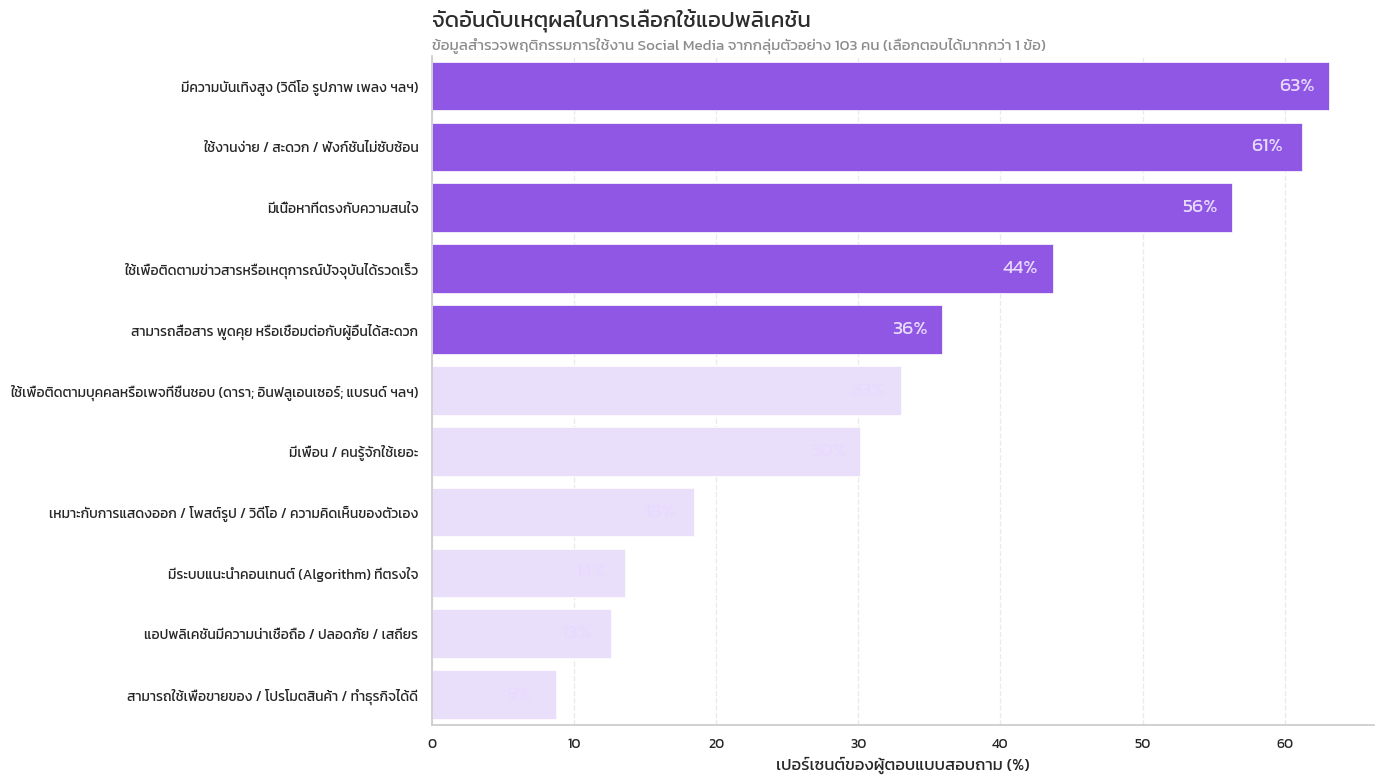

In [40]:
reason_colors = ['#8a3ffc', '#8a3ffc', '#8a3ffc', '#8a3ffc', '#8a3ffc', '#e8daff', '#e8daff', '#e8daff', '#e8daff', '#e8daff', '#e8daff']

subtitle_text3 = f"ข้อมูลสำรวจพฤติกรรมการใช้งาน Social Media จากกลุ่มตัวอย่าง {total_survey} คน (เลือกตอบได้มากกว่า 1 ข้อ)"

plt.figure(figsize=(14, 8))

ax = sns.barplot(
    data=app_reason_counts,
    x='Percentage',
    y='Reason',
    palette=reason_colors,
    edgecolor='white',
    linewidth=0.5
)

sns.despine()
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.title("จัดอันดับเหตุผลในการเลือกใช้แอปพลิเคชัน", loc='left', fontsize=16, fontweight='bold', color='#2c2c2c', pad=20)
plt.text(x=0, y=-0.6, s=subtitle_text3, fontsize=11, color='#8c8c8c')
plt.xlabel('เปอร์เซนต์ของผู้ตอบแบบสอบถาม (%)')
plt.ylabel('')

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f%%', fontsize=14, fontweight='bold', padding=-36, color='#e8daff')

plt.tight_layout()
plt.show()

#### Insight 5 - ช่วงเวลาในการใช้งานแอปพลิเคชัน

In [41]:
cross_tab_prop2 = pd.crosstab(index=data['ActiveTimeClean'], columns=data['FavoriteAppClean'])
cross_tab_prop2

FavoriteAppClean,Facebook,Instagram,Others,Tiktok,Twitter (X),YouTube
ActiveTimeClean,,,,,,
00.00 - 06.00 น. (ช่วงดึก),0,1,0,1,0,0
06.00 - 12.00 น. (ช่วงเช้า),3,0,1,0,0,2
12.00 - 18.00 น. (ช่วงบ่าย),4,6,0,5,2,3
18.00 - 24.00 น. (ช่วงกลางคืน),7,11,2,32,8,10
อื่น ๆ / ไม่ระบุเวลา,2,1,0,1,0,1


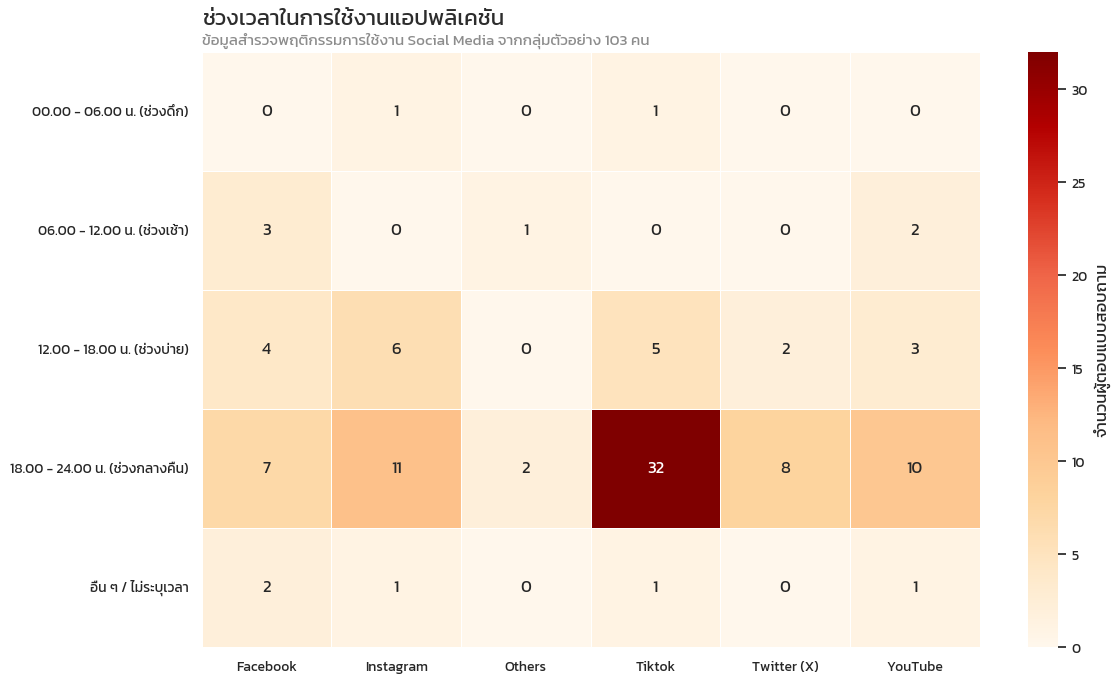

In [42]:
subtitle_text4 = f"ข้อมูลสำรวจพฤติกรรมการใช้งาน Social Media จากกลุ่มตัวอย่าง {total_survey} คน"

plt.figure(figsize=(12, 7))

sns.heatmap(cross_tab_prop2, annot=True, fmt='.0f', cmap='OrRd', linewidths=0.5, cbar_kws={'label': 'จำนวนผู้ตอบแบบสอบถาม'})

plt.title("ช่วงเวลาในการใช้งานแอปพลิเคชัน", loc='left', fontsize=16, fontweight='bold', color='#2c2c2c', pad=20)
plt.text(x=0, y=-0.07, s=subtitle_text4, fontsize=11, color='#8c8c8c')
plt.xlabel('')
plt.ylabel('')

plt.tight_layout()
plt.show()

**จากกราฟที่ได้ พบประเด็นที่สำคัญดังนี้**
- ผู้ตอบแบบสอบถามส่วนใหญ่มักใช้งานแอปพลิเคชันในช่วงกลางคืน
- ในช่วงกลางคืน มีผู้ใช้งานแอปพลิเคชัน TikTok มากที่สุด ตามมาด้วย Instagram และ YouTube รองลงมา

#### Insight 6 - ระยะเวลาการใช้งาน Social Media ต่อวันในแต่ละอาชีพ

In [43]:
cross_tab_prop3 = pd.crosstab(index=new_data['JobsRename'], columns=new_data['DailyUsageHours'])
job_order = ['อื่น ๆ', 'เกษียณอายุ', 'ว่างงาน', 'แม่บ้าน / พ่อบ้าน', 'ค้าขาย', 'ผู้ประกอบการ', 'วิศวกร / IT', 'ข้าราชการ', 'พนักงานบริษัท', 'นักเรียน']
cross_tab_prop3 = cross_tab_prop3.reindex(job_order)
cross_tab_prop3

DailyUsageHours,1 - 2 ชั่วโมง,3 - 4 ชั่วโมง,มากกว่า 4 ชั่วโมง
JobsRename,,,
อื่น ๆ,0,1,0
เกษียณอายุ,0,1,0
ว่างงาน,1,1,1
แม่บ้าน / พ่อบ้าน,0,2,0
ค้าขาย,0,0,2
ผู้ประกอบการ,1,1,3
วิศวกร / IT,1,2,2
ข้าราชการ,2,0,4
พนักงานบริษัท,2,1,5


In [44]:
cross_tab_percent3 = cross_tab_prop3.div(cross_tab_prop3.sum(1), axis=0) * 100

<Figure size 1200x700 with 0 Axes>

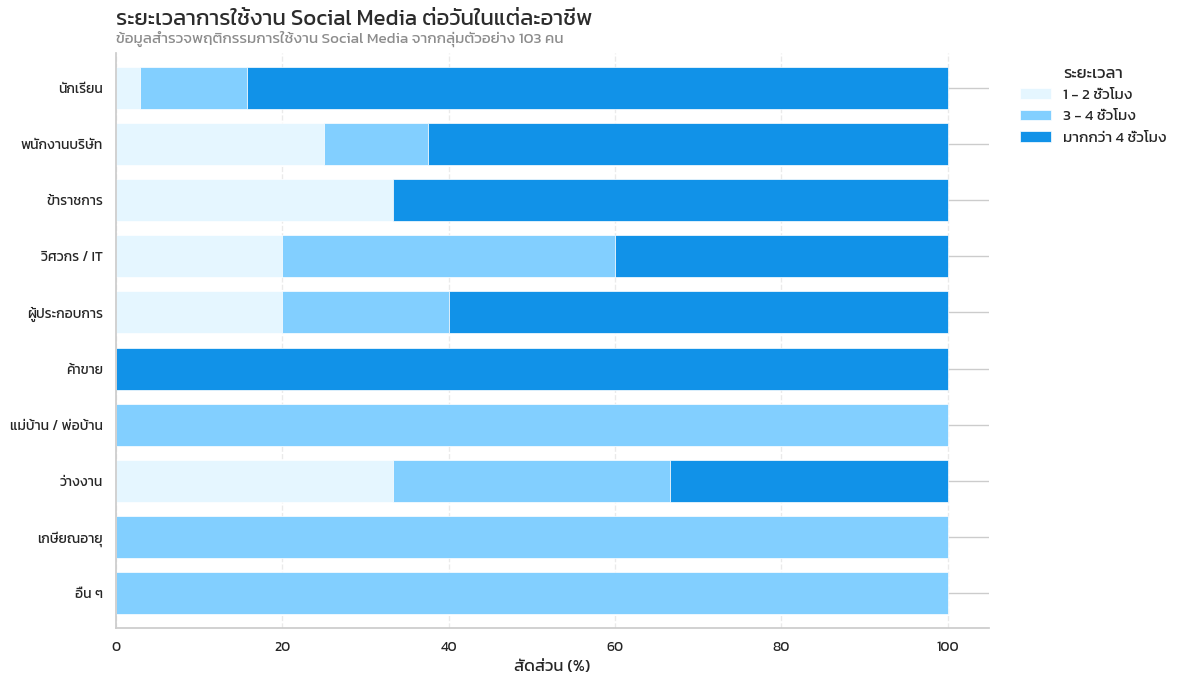

In [45]:
colors = ['#e5f6ff', '#82cfff', '#1192e8']

subtitle_text5 = f"ข้อมูลสำรวจพฤติกรรมการใช้งาน Social Media จากกลุ่มตัวอย่าง {total_survey} คน"

plt.figure(figsize=(12, 7))
cross_tab_percent3.plot(kind='barh',
                    stacked=True,
                    color=colors,
                    figsize=(12, 7),
                    width=0.75,
                    edgecolor='white',
                    linewidth=0.5)
sns.despine()
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.xlabel('สัดส่วน (%)')
plt.ylabel('')
plt.title("ระยะเวลาการใช้งาน Social Media ต่อวันในแต่ละอาชีพ", loc='left', fontsize=16, fontweight='bold', color='#2c2c2c', pad=20)
plt.text(x=0, y=9.8, s=subtitle_text5, fontsize=11, color='#8c8c8c')
plt.legend(title='ระยะเวลา', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)

plt.tight_layout()
plt.show()

**จากกราฟที่ได้ พบประเด็นที่สำคัญดังนี้**
- ผู้ตอบแบบสอบถามส่วนใหญ่มักใช้งาน Social Media มากกว่า 4 ชั่วโมงต่อวัน
- อาชีพนักเรียน พนักงานบริษัท ข้าราชการ ผู้ประกอบการ ค้าขาย ส่วนใหญ่ใช้งาน Social Media มากกว่า 4 ชั่วโมงต่อวัน
- ส่วนอาชีพแม่บ้านหรือพ่อบ้าน เกษียณอายุ และอาชีพอื่น ๆ ใช้งาน Social Media 3 - 4 ชั่วโมงต่อวัน

### Data Preprocessing

In [46]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

- ทำการเลือก Features และ Target

In [47]:
X = new_data[['Age', 'Gender', 'Jobs', 'DailyUsageHours', 'ActiveTimeClean', 'SocialMediaReason', 'AppReason', 'UsageYears']]
y = new_data['FavoriteAppClean']

- แบ่งกลุ่ม Features แต่ละหมวดหมู่

In [48]:
numeric_features = ['Age']
categorical_features = ['Gender', 'Jobs', 'DailyUsageHours', 'ActiveTimeClean', 'UsageYears']
text_features = ['SocialMediaReason', 'AppReason']

In [49]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ('text1', TfidfVectorizer(ngram_range=(1, 2), max_features=3000), text_features[0]),
    ('text2', TfidfVectorizer(ngram_range=(1, 2), max_features=3000), text_features[1])
])

### Modeling

#### 1. Logistic Regression

In [50]:
model1 = Pipeline([
    ('preprocess', preprocessor),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

In [51]:
X_train1, X_test1, y_train1, y_test1 = train_test_split(X, y, test_size=0.2, random_state=42)
model1.fit(X_train1, y_train1)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Gender', 'Jobs',
                                                   'DailyUsageHours',
                                                   'ActiveTimeClean',
                                                   'UsageYears']),
                                                 ('text1',
                                                  TfidfVectorizer(max_features=3000,
                                                                  ngram_range=(1,
                                                                               2)),
                                                  'SocialMediaReason'),
                                                 ('text2',
                                                  TfidfVectorizer(max_features=3000,
                                                                  ngram_range=(1,
                                                                               2)),
                                                  'AppReason')])),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

#### Testing

- ดูค่า accuracy ของ model ที่ได้

In [52]:
print("Accuracy:", model1.score(X_test1, y_test1))

Accuracy: 0.6666666666666666


- แสดงผล score ของ model ที่ได้

In [53]:
from sklearn.metrics import classification_report, confusion_matrix

In [55]:
y_pred1 = model1.predict(X_test1)
print(classification_report(y_test1, y_pred1, digits=2))

              precision    recall  f1-score   support

    Facebook       0.71      0.83      0.77         6
   Instagram       0.50      0.67      0.57         3
      Others       0.00      0.00      0.00         1
      Tiktok       0.71      0.83      0.77         6
 Twitter (X)       0.50      0.50      0.50         2
     YouTube       1.00      0.33      0.50         3

    accuracy                           0.67        21
   macro avg       0.57      0.53      0.52        21
weighted avg       0.67      0.67      0.64        21



C:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

- Confusion Matrix ของ model ที่ได้

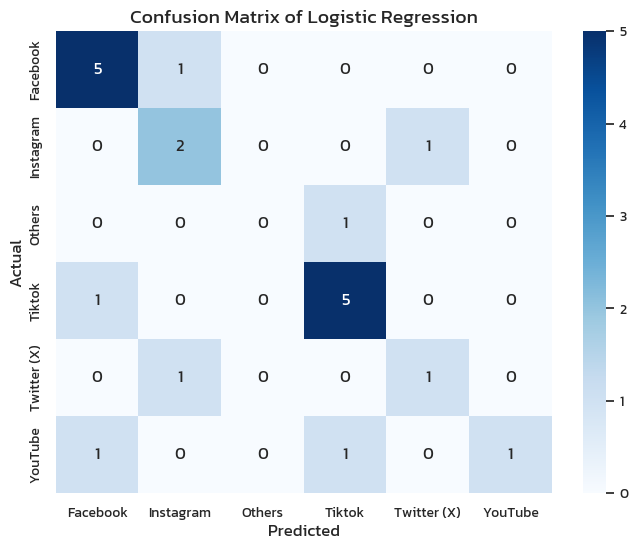

In [56]:
cm1 = confusion_matrix(y_test1, y_pred1, labels=model1.classes_)

plt.figure(figsize=(8,6))
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues',
            xticklabels=model1.classes_,
            yticklabels=model1.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix of Logistic Regression")
plt.show()

#### 2. Random Forest

In [58]:
from sklearn.ensemble import RandomForestClassifier

In [59]:
model2 = Pipeline([
    ('preprocess', preprocessor),
    ('clf', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42))
])

In [60]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(X, y, test_size=0.2, random_state=42)
model2.fit(X_train2, y_train2)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Gender', 'Jobs',
                                                   'DailyUsageHours',
                                                   'ActiveTimeClean',
                                                   'UsageYears']),
                                                 ('text1',
                                                  TfidfVectorizer(max_features=3000,
                                                                  ngram_range=(1,
                                                                               2)),
                                                  'SocialMediaReason'),
                                                 ('text2',
                                                  TfidfVectorizer(max_features=3000,
                                                                  ngram_range=(1,
                                                                               2)),
                                                  'AppReason')])),
                ('clf',
                 RandomForestClassifier(class_weight='balanced',
                                        random_state=42))])

#### Testing

In [61]:
print("Accuracy:", model2.score(X_test2, y_test2))

Accuracy: 0.42857142857142855


In [62]:
y_pred2 = model2.predict(X_test2)
print(classification_report(y_test2, y_pred2, digits=2))

              precision    recall  f1-score   support

    Facebook       1.00      0.17      0.29         6
   Instagram       0.29      0.67      0.40         3
      Others       0.00      0.00      0.00         1
      Tiktok       0.50      1.00      0.67         6
 Twitter (X)       0.00      0.00      0.00         2
     YouTube       0.00      0.00      0.00         3

    accuracy                           0.43        21
   macro avg       0.30      0.31      0.23        21
weighted avg       0.47      0.43      0.33        21



C:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

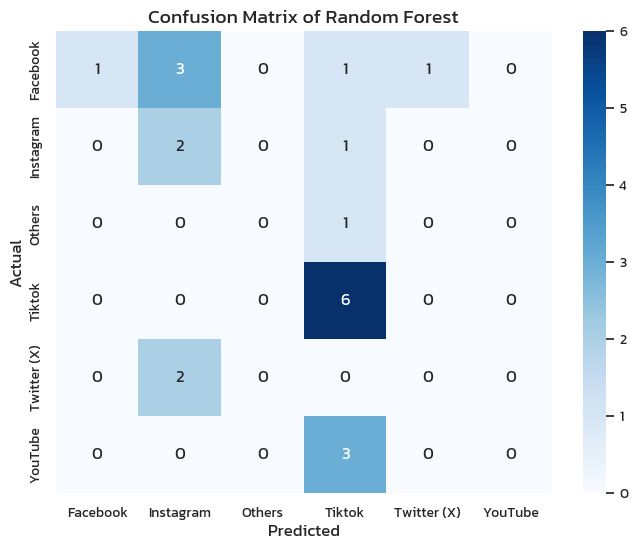

In [63]:
cm2 = confusion_matrix(y_test2, y_pred2, labels=model2.classes_)

plt.figure(figsize=(8,6))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues',
            xticklabels=model2.classes_,
            yticklabels=model2.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix of Random Forest")
plt.show()

#### 3. XGBoost

In [64]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

- แปลง Target ให้เป็นตัวเลขก่อนทำการ train

In [65]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [66]:
model3 = Pipeline([
    ('preprocess', preprocessor),
    ('clf', XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, eval_metric='mlogloss', random_state=42))
])

In [67]:
X_train3, X_test3, y_train3, y_test3 = train_test_split(X, y_encoded, test_size=0.2, random_state=42)
model3.fit(X_train3, y_train3)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Gender', 'Jobs',
                                                   'DailyUsageHours',
                                                   'ActiveTimeClean',
                                                   'UsageYears']),
                                                 ('text1',
                                                  TfidfVectorizer(max_features=3000,
                                                                  ngram_range=(1,
                                                                               2)),
                                                  'SocialMediaReason'),
                                                 ('text2',
                                                  TfidfVectorizer(max_features=3000,
                                                                  ngram_range=(1,...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=100, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [68]:
print("Accuracy:", model3.score(X_test3, y_test3))

Accuracy: 0.6666666666666666


In [69]:
y_pred3 = model3.predict(X_test3)
print(classification_report(y_test3, y_pred3, digits=2))

              precision    recall  f1-score   support

           0       1.00      0.67      0.80         6
           1       0.50      1.00      0.67         3
           2       0.00      0.00      0.00         1
           3       0.67      1.00      0.80         6
           4       0.00      0.00      0.00         2
           5       1.00      0.33      0.50         3

    accuracy                           0.67        21
   macro avg       0.53      0.50      0.46        21
weighted avg       0.69      0.67      0.62        21



C:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

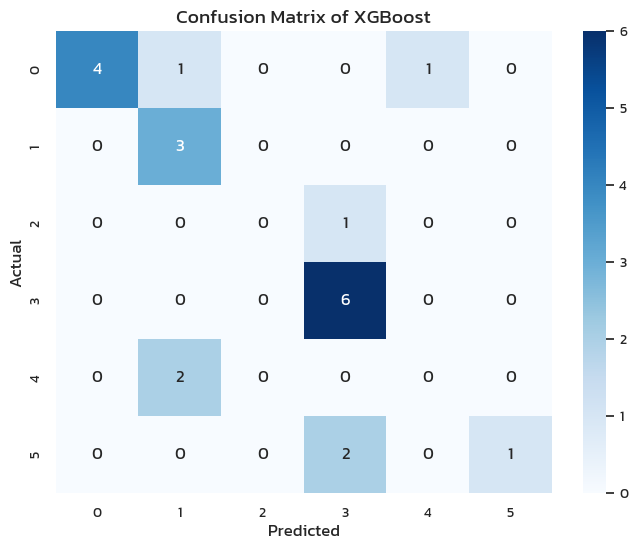

In [70]:
cm3 = confusion_matrix(y_test3, y_pred3, labels=model3.classes_)

plt.figure(figsize=(8,6))
sns.heatmap(cm3, annot=True, fmt='d', cmap='Blues',
            xticklabels=model3.classes_,
            yticklabels=model3.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix of XGBoost")
plt.show()

### Summary

**จากการทำ model สามารถสรุปได้ดังนี้**
- โมเดลที่ 1 (Logistic Regression) มีค่า accuracy เท่ากับโมเดลที่ 3 (XGBoost) แต่เมื่อประเมินผลจาก Classification Report ที่ได้ โมเดลที่ 1 จะมีค่า macro avg (f1-score) ที่สูงกว่าในโมเดลที่ 3
- และจาก Confusion Matrix ที่ได้ โมเดลที่ 1 สามารถทำนาย Twitter class ได้ถูกต้องบางส่วน แต่ในโมเดลที่ 3 ไม่สามารถทำนายได้ถูกต้อง
- ส่วนในโมเดลที่ 2 (Random Forest) มีค่า accuracy และประสิทธิภาพในการทำนายผลน้อยที่สุด
- ดังนั้น โมเดลที่ 1 (Logistic Regression) จึงเหมาะสมที่สุดในการทำนายผล

- เก็บ model1 ที่ทำการ train แล้วไว้ในไฟล์ชื่อ fav_app_model.joblib

In [71]:
import joblib
joblib.dump(model1, "fav_app_model.joblib")

['fav_app_model.joblib']